In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt

with open('../input/emnist_source_files/emnist-bymerge-train-images-idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    train_data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    train_data = train_data.reshape((size,nrows,ncols))
print('Train images shape : ',np.shape(train_data))
with open('../input/emnist_source_files/emnist-bymerge-test-images-idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    test_data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    test_data = test_data.reshape((size,nrows,ncols))
print('Test images shape : ',np.shape(test_data))
with open('../input/emnist_source_files/emnist-bymerge-train-labels-idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    train_labels = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    train_labels = train_labels.reshape((size,))
print('Train labels shape : ',np.shape(train_labels))
with open('../input/emnist_source_files/emnist-bymerge-test-labels-idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    test_labels = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    test_labels = test_labels.reshape((size,))
print('Test labels shape : ',np.shape(test_labels))

class_map = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'
number_of_classes = len(class_map)
print('Class size : ', number_of_classes)


Train images shape :  (697932, 28, 28)
Test images shape :  (116323, 28, 28)
Train labels shape :  (697932,)
Test labels shape :  (116323,)
Class size :  47


Test correct image correspondence with label
(116323, 28, 28)
(28, 28)


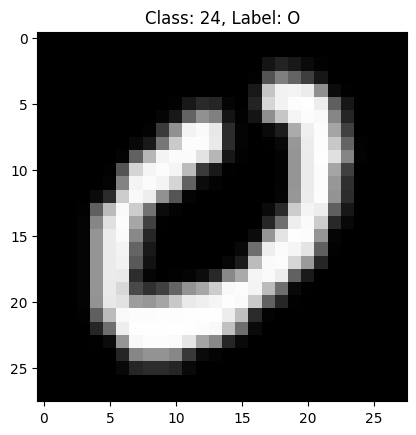

In [2]:
def show_img(data, labels, row_num):
    print(data.shape)
    print(data[row_num].shape)
    img_flip = np.transpose(data[row_num], axes=[1,0]) # img_size * img_size arrays
    plt.title('Class: ' + str(labels[row_num]) + ', Label: ' + str(class_map[labels[row_num]]))
    plt.imshow(img_flip, cmap='Greys_r')
print("Test correct image correspondence with label")
show_img(test_data, test_labels, 0)

In [6]:
def setTensorflowGPUParams():
    from os import environ
    environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
    environ['KERAS_BACKEND'] = 'tensorflow'
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    tf.debugging.set_log_device_placement(True)
    tf.test.is_gpu_available()
    devices = tf.config.experimental.list_physical_devices('GPU')
    GPU = devices[0]
    try:
        tf.config.experimental.set_memory_growth(GPU, True)
    except:
        pass
setTensorflowGPUParams()

2024-02-24 14:02:26.676187: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 14:02:26.676409: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 14:02:26.676566: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Data normalisation
train_data = train_data / 255.0
test_data = test_data / 255.0

train_data_size = train_data.shape[0]
train_data_height = 28
train_data_width = 28
train_data_img_size = train_data_height*train_data_width

train_data = train_data.reshape(train_data_size, train_data_height, train_data_width, 1)

test_data_size = test_data.shape[0]
test_data_height = 28
test_data_width = 28
test_data_img_size = test_data_height*test_data_width

test_data = test_data.reshape(test_data_size, test_data_height, test_data_width, 1)

# Transform labels
train_labels = to_categorical(train_labels, number_of_classes)
test_labels = to_categorical(test_labels, number_of_classes)
# Split some data for validation
train_data, validation_data, train_labels, validation_labels = train_test_split(train_data, train_labels, test_size=0.2, random_state=42)

print("###### Final shapes ######")
print("Train data shape : ", np.shape(train_data), "\tTrain labels shape : ", np.shape(train_labels))
print("Test data shape : ", np.shape(test_data), "\t\tTest labels shape : ", np.shape(test_labels))
print("Validation data shape : ", np.shape(validation_data), "\tValidation labels shape : ", np.shape(validation_labels))

2024-02-24 13:42:21.763524: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-24 13:42:21.763555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-24 13:42:21.764511: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-24 13:42:21.770129: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-24 13:42:22.407724: W tensorflow/compiler/tf2

###### Final shapes ######
Train data shape :  (558345, 28, 28, 1) 	Train labels shape :  (558345, 47)
Test data shape :  (116323, 28, 28, 1) 		Test labels shape :  (116323, 47)
Validation data shape :  (139587, 28, 28, 1) 	Validation labels shape :  (139587, 47)


In [6]:
setTensorflowGPUParams()

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Convolution-subsampling pairs
# https://www.kaggle.com/code/cdeotte/how-to-choose-cnn-architecture-mnist/notebook#1.-How-many-convolution-subsambling-pairs?
nets = 3
model = [0] *nets
names = ["(C-P)x1","(C-P)x2","(C-P)x3"]

for j in range(nets):
    model[j] = Sequential()
    model[j].add(Conv2D(24, kernel_size=5, padding='same', activation='relu', input_shape=(28, 28, 1)))
    model[j].add(MaxPooling2D())
    if j>0:
        model[j].add(Conv2D(48, kernel_size=5, padding='same', activation='relu'))
        model[j].add(MaxPooling2D())
    if j>1:
        model[j].add(Conv2D(64, kernel_size=5, padding='same', activation='relu'))
        model[j].add(MaxPooling2D(padding='same'))
    model[j].add(Flatten())
    model[j].add(Dense(256, activation='relu'))
    model[j].add(Dense(number_of_classes, activation='softmax'))
    model[j].compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = [0] * nets
epochs = 20
batch_size = 64
for j in range(nets):
    history[j] = model[j].fit(train_data, train_labels, batch_size=batch_size, epochs=epochs, validation_data=(validation_data, validation_labels), verbose=3)
    print("CNN {0}: Epochs={1:d}, Train accuracy={2:.5f}, Validation accuracy={3:.5f}".format(names[j],epochs,max(history[j].history['accuracy']),max(history[j].history['val_accuracy']) ))

2024-02-24 12:55:34.543530: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 12:55:34.543737: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 12:55:34.543883: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Epoch 1/20


2024-02-24 12:55:38.118187: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-02-24 12:55:39.048025: I external/local_xla/xla/service/service.cc:168] XLA service 0x92f9380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-24 12:55:39.048053: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2024-02-24 12:55:39.063573: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1708775739.148465   14212 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20
CNN (C-P)x1: Epochs=20, Train accuracy=0.95185, Validation accuracy=0.89612
Epoch 1/20
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20
CNN (C-P)x2: Epochs=20, Train accuracy=0.94414, Validation accuracy=0.90190
Epoch 1/20
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20
CNN (C-P)x3: Epochs=20, Train accuracy=0.92781, Validation accuracy=0.90202


In [7]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Feature maps
nets = 6
model = [0] *nets
for j in range(6):
    model[j] = Sequential()
    model[j].add(Conv2D(j*8+8,kernel_size=5,activation='relu',input_shape=(28,28,1)))
    model[j].add(MaxPooling2D())
    model[j].add(Conv2D(j*16+16,kernel_size=5,activation='relu'))
    model[j].add(MaxPooling2D())
    model[j].add(Flatten())
    model[j].add(Dense(256, activation='relu'))
    model[j].add(Dense(number_of_classes, activation='softmax'))
    model[j].compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
history = [0] * nets
names = ["8 maps","16 maps","24 maps","32 maps","48 maps","64 maps"]
epochs = 20
batch_size = 64
for j in range(nets):
    history[j] = model[j].fit(train_data, train_labels, batch_size=batch_size, epochs=epochs, validation_data=(validation_data, validation_labels), verbose=2)
    print("CNN {0}: Epochs={1:d}, Train accuracy={2:.5f}, Validation accuracy={3:.5f}".format(names[j],epochs,max(history[j].history['accuracy']),max(history[j].history['val_accuracy']) ))

2024-02-24 14:02:44.111596: W external/local_tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.63GiB (rounded to 1750970112)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2024-02-24 14:02:44.111634: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2024-02-24 14:02:44.111650: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 135, Chunks in use: 135. 33.8KiB allocated for chunks. 33.8KiB in use in bin. 6.5KiB client-requested in use in bin.
2024-02-24 14:02:44.111662: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 5, Chunks in use: 4. 2.5KiB allocated for chunks. 2.0KiB in use in bin. 1.4KiB client-requested in use in bin.
2024-02-24 14:02:44.1

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

llocated for chunks. 7.50MiB in use in bin. 7.50MiB client-requested in use in bin.
2024-02-24 14:02:44.111796: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (2097152): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2024-02-24 14:02:44.111806: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (4194304): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2024-02-24 14:02:44.111816: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (8388608): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2024-02-24 14:02:44.111827: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (16777216): 	Total Chunks: 1, Chunks in use: 1. 25.03MiB allocated for chunks. 25.03MiB in use in bin. 25.03MiB client-requested in use in bin.
2024-02-24 14:02:44.111837: I externa

ramework/bfc_allocator.cc:1103] 1 Chunks of size 13568 totalling 13.2KiB
2024-02-24 14:02:44.113350: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 12 Chunks of size 48128 totalling 564.0KiB
2024-02-24 14:02:44.113357: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 5 Chunks of size 51200 totalling 250.0KiB
2024-02-24 14:02:44.113363: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 1 Chunks of size 60416 totalling 59.0KiB
2024-02-24 14:02:44.113369: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 1 Chunks of size 67072 totalling 65.5KiB
2024-02-24 14:02:44.113375: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 1 Chunks of size 72448 totalling 70.8KiB
2024-02-24 14:02:44.113381: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 2 Chunks of size 115200 totalling 225.0KiB
2024-02-24 14:02:44.113387: I external/local_tsl/tsl/framework/bfc_allocator.cc:1103] 2 Chunks of size 204800 totalling 400.0KiB
2024-02-24 14:02:44.113393: I e

In [6]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import json

model = tf.keras.Sequential([
    #tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=24, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(filters=48, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(padding='same'),
    tf.keras.layers.Flatten(),
    #################################################
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(number_of_classes, activation='softmax')
])
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer= opt,loss='categorical_crossentropy',metrics=tf.keras.metrics.CategoricalAccuracy())

es = EarlyStopping(monitor='val_loss', mode='max', verbose=1, patience=10)
mc = ModelCheckpoint('combined_emnist_model.h5', monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True, patience=5)
history = model.fit(train_data, train_labels, batch_size=256 , epochs=100, validation_data= (validation_data,validation_labels) , callbacks=[es,mc], verbose=1)
with open('history.json', 'w') as f:
    json.dump(history.history, f)

2024-02-23 16:21:06.907935: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:306] gpu_async_0 cuMemAllocAsync failed to allocate 1750969920 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 215941120/8134197248
2024-02-23 16:21:06.907974: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:311] Stats: Limit:                        19660800
InUse:                         9606952
MaxInUse:                     13702764
NumAllocs:                         266
MaxAllocSize:                  2097152
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2024-02-23 16:21:06.907991: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:63] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2024-02-23 16:21:06.907997: E external/local_xla/xla/stream_executor/

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('combined_emnist_model.h5')

def evaluate(testX, testY, model):
    scores, histories = list(), list()
    _, acc = model.evaluate(testX, testY, verbose=0)
    print('> %.3f' % (acc * 100.0))
    scores.append(acc)
    histories.append(history)
    return scores, histories

def summarize_diagnostics(histories):
    for index in range(len(histories)):
        # LOSS
        plt.subplot(2,1,1)
        plt.title('Cross Entropy Loss')
        plt.plot(histories[index].history['loss'], color='blue', label='train')
        plt.plot(histories[index].history['val_loss'], color='orange', label='test')
        # ACCURACY
        plt.subplot(2,2,2)
        plt.title('Classification Categorical Accuracy')
        plt.plot(histories[index].history['categorical_accuracy'], color='blue', label='train')
        plt.plot(histories[index].history['val_categorical_accuracy'], color='orange', label='test')
        plt.show()

def summarize_performance(scores):
    print('Accuracy: mean=%.3f std=%.3f n=%d' % (np.mean(scores)*100, np.std(scores)*100, len(scores)))

model = load_model('combined_emnist_model.h5')
scores, histories = evaluate(test_data, test_labels, model)
summarize_diagnostics(histories)
summarize_performance(scores)

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, "model.png", show_shapes=True)